# Chess Move Transformer — Baseline
### Decoder-only Transformer for Human Move Prediction · Same 2200–2600 ELO Lichess dataset

---

## Overview

This is the DL follow-up to the LightGBM ranker baseline: instead of ranking legal moves with
hand-engineered board + move features, we treat a game as a **sequence of moves** and train a
small **decoder-only transformer** (GPT-style) to predict the next move token, autoregressively,
from the move history alone.

| | |
|---|---|
| **Task** | Predict the next move given the sequence of moves played so far |
| **Approach** | Decoder-only transformer, next-move-token cross-entropy, causal self-attention |
| **Tokenization** | One token = one full move, over the **full UCI action space** (board-independent, fixed vocabulary) |
| **Legality** | Guaranteed by masking the model's output to the legal moves in the *actual* position (computed via `python-chess`), never by trusting the model's own belief about the board |
| **Evaluation** | Legal-move-masked Top-1 / Top-3 accuracy on held-out games — directly comparable to the LightGBM ranker's numbers |

This notebook is a **baseline**: it is intentionally small (few million parameters, a handful of
epochs) so it trains fast and gives you a working, correct pipeline end-to-end. The "Summary &
Next Steps" section at the bottom lists the obvious levers once this runs cleanly.

---

## Notebook Structure

| # | Section | Description |
|---|---|---|
| 1 | **Setup** | Imports, config, device |
| 2 | **Load Filtered Games** | Same PGN source and ELO filter as the LightGBM baseline |
| 3 | **Game-Level Split** | Same game-level 80/20 split — no position leakage |
| 4 | **Move Vocabulary** | Full UCI action-space vocab (board-independent, fixed size) |
| 5 | **Encoding Games** | Games → sequences of move-token ids |
| 6 | **Dataset & DataLoader** | Padding, causal LM shift, batching |
| 7 | **Model** | Decoder-only transformer (causal self-attention, from scratch) |
| 8 | **Training** | Next-token cross-entropy, train/val loss curves |
| 9 | **Legal-Move-Masked Evaluation** | Top-1 / Top-3 accuracy + a tracking-quality diagnostic |
| 10 | **Save Artifacts** | Persist weights + vocabulary |
| 11 | **Summary & Next Steps** | What this baseline does and doesn't tell you yet |


---
# 1. Setup & Config

In [3]:
import os
import json
import math
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import chess
import chess.pgn
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else ("mps" if torch.backends.mps.is_available() else "cpu")
)
print("Using device:", device)


Using device: mps


---
# 2. Load Filtered Games

Same source PGN and same ELO filter as the LightGBM ranker baseline, so the two models are
trained/evaluated on the same population of games. Adjust `pgn_path` if your file lives elsewhere.

In [4]:
pgn_path = "lichess_elite_2019-10.pgn"   # same source file as the LightGBM baseline
min_elo = 2200
max_elo = 2600
max_games = 15000
min_moves = 8      # drop very short games (aborted/administrative)
max_moves = 200    # drop extreme outlier-length games

games = []

with open(pgn_path) as f:
    while True:
        game = chess.pgn.read_game(f)
        if game is None:
            break

        try:
            w_elo = int(game.headers.get("WhiteElo", 0))
            b_elo = int(game.headers.get("BlackElo", 0))
        except ValueError:
            continue

        if not (min_elo <= w_elo <= max_elo and min_elo <= b_elo <= max_elo):
            continue

        move_count = sum(1 for _ in game.mainline_moves())
        if move_count < min_moves or move_count > max_moves:
            continue

        games.append(game)
        if len(games) >= max_games:
            break

print(f"Total filtered games loaded: {len(games)}")
print(f"ELO range: {min_elo}-{max_elo}")


Total filtered games loaded: 15000
ELO range: 2200-2600


---
# 3. Game-Level Train/Test Split

Split by **game**, not by position — otherwise positions from the same game leak between train
and test (same issue the LightGBM notebook was careful about). Same seed, so if you point both
notebooks at the same PGN file you get the same split.

In [5]:
train_games, test_games = train_test_split(games, test_size=0.2, random_state=SEED)

print(f"Train games: {len(train_games)}")
print(f"Test games:  {len(test_games)}")


Train games: 12000
Test games:  3000


---
# 4. Move Vocabulary — Full UCI Action Space

Rather than building the vocabulary from whatever moves happen to appear in the training data
(which would leave the model unable to even *express* a legal move it never saw played), we
enumerate the **entire space of UCI move strings** `python-chess` can produce. This is the same
trick AlphaZero-style engines use for their policy head (a fixed action space), just expressed as
plain UCI strings instead of move-planes.

This means: every legal move in every legal chess position has a slot in this vocabulary, whether
or not it ever showed up in training. Masking to legal moves at inference time (next section
onward) is then guaranteed to always have somewhere valid to point.

In [6]:
PROMOTION_PIECES = [chess.QUEEN, chess.ROOK, chess.BISHOP, chess.KNIGHT]

def generate_full_uci_vocab():
    # All UCI move strings python-chess can emit, independent of any specific board.
    moves = set()

    for from_sq in chess.SQUARES:
        for to_sq in chess.SQUARES:
            if from_sq == to_sq:
                continue

            from_rank = chess.square_rank(from_sq)
            to_rank = chess.square_rank(to_sq)
            is_promotion_rank = (from_rank == 6 and to_rank == 7) or (from_rank == 1 and to_rank == 0)

            # Always add the plain move -- this square transition could be any
            # piece (a rook sliding from a2 to a1 is NOT a promotion).
            moves.add(chess.Move(from_sq, to_sq).uci())

            if is_promotion_rank:
                # If it IS a pawn making this exact transition, python-chess always
                # emits an explicit promotion move (e7e8q/r/b/n), never a bare "e7e8".
                # Add those variants too so pawn promotions are also covered.
                for promo in PROMOTION_PIECES:
                    moves.add(chess.Move(from_sq, to_sq, promotion=promo).uci())

    return sorted(moves)


SPECIAL_TOKENS = ["<PAD>", "<BOS>"]

uci_vocab = generate_full_uci_vocab()
itos = SPECIAL_TOKENS + uci_vocab
stoi = {tok: i for i, tok in enumerate(itos)}

PAD_ID = stoi["<PAD>"]
BOS_ID = stoi["<BOS>"]

VOCAB_SIZE = len(itos)
print(f"Vocabulary size: {VOCAB_SIZE}  ({len(uci_vocab)} moves + {len(SPECIAL_TOKENS)} special tokens)")


Vocabulary size: 4546  (4544 moves + 2 special tokens)


---
# 5. Encoding Games as Move-Token Sequences

Each game becomes `[<BOS>, move_1, move_2, ..., move_n]`. Note we tokenize **move-by-move**, not
character-by-character over PGN/SAN text (unlike Karvonen's Chess-GPT) — this trades away nothing
in expressiveness here since our vocab already covers the full action space, and it makes the
legal-move masking step trivial later (one softmax over one move-level vocabulary, instead of
constrained decoding across multiple characters per move).

In [7]:
def encode_game(game):
    ids = [BOS_ID]
    for move in game.mainline_moves():
        ids.append(stoi[move.uci()])
    return ids


train_sequences = [encode_game(g) for g in tqdm(train_games, desc="Encoding train games")]
test_sequences  = [encode_game(g) for g in tqdm(test_games, desc="Encoding test games")]

lengths = [len(s) for s in train_sequences]
print(f"Train sequences: {len(train_sequences)}")
print(f"Sequence length (plies) -- min: {min(lengths)}, max: {max(lengths)}, mean: {np.mean(lengths):.1f}")


Encoding test games: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 3000/3000 [00:00<00:00, 54339.04it/s]

Train sequences: 12000
Sequence length (plies) -- min: 9, max: 201, mean: 82.5


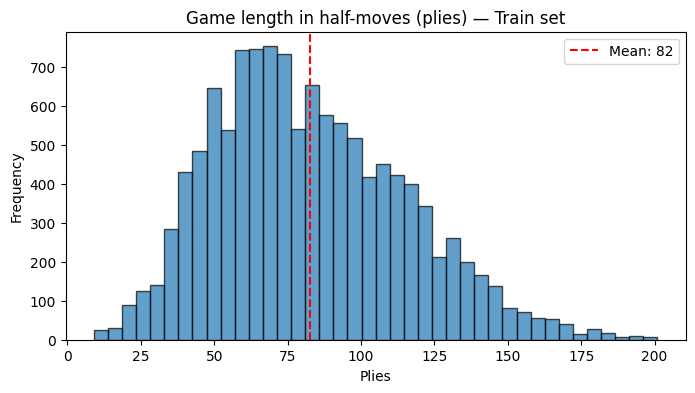

In [8]:
plt.figure(figsize=(8, 4))
plt.hist(lengths, bins=40, edgecolor="black", alpha=0.7)
plt.axvline(np.mean(lengths), color="red", linestyle="--", label=f"Mean: {np.mean(lengths):.0f}")
plt.title("Game length in half-moves (plies) — Train set")
plt.xlabel("Plies")
plt.ylabel("Frequency")
plt.legend()
plt.show()


---
# 6. Dataset & DataLoader

Standard causal language-modeling setup: input is the sequence shifted left by one, target is the
sequence shifted right by one. Games longer than `BLOCK_SIZE` plies are truncated (a real
limitation for very long games — see Next Steps). Padding tokens are masked out of both attention
and the loss.

In [9]:
BLOCK_SIZE = 160  # max context length in plies

class ChessMoveDataset(Dataset):
    def __init__(self, sequences, block_size=BLOCK_SIZE):
        self.block_size = block_size
        self.sequences = [s[: block_size + 1] for s in sequences if len(s) >= 2]

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        seq = self.sequences[idx]
        x = seq[:-1]
        y = seq[1:]
        return torch.tensor(x, dtype=torch.long), torch.tensor(y, dtype=torch.long)


def collate_batch(batch):
    xs, ys = zip(*batch)
    max_len = max(len(x) for x in xs)

    x_pad = torch.full((len(xs), max_len), PAD_ID, dtype=torch.long)
    y_pad = torch.full((len(ys), max_len), -100, dtype=torch.long)  # -100 -> ignored by cross-entropy

    for i, (x, y) in enumerate(zip(xs, ys)):
        x_pad[i, : len(x)] = x
        y_pad[i, : len(y)] = y

    return x_pad, y_pad


train_dataset = ChessMoveDataset(train_sequences)
test_dataset  = ChessMoveDataset(test_sequences)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, collate_fn=collate_batch)
val_loader   = DataLoader(test_dataset, batch_size=64, shuffle=False, collate_fn=collate_batch)

print(f"Train samples (games): {len(train_dataset)}")
print(f"Val samples (games):   {len(test_dataset)}")


Train samples (games): 12000
Val samples (games):   3000


---
# 7. Model — Decoder-Only Transformer

A small GPT-style architecture built from scratch: token + positional embeddings, a stack of
causal self-attention blocks, LayerNorm, MLP, and a linear head projecting to the full move
vocabulary. Padding is masked out of attention as well as the loss.

In [10]:
class CausalSelfAttention(nn.Module):
    def __init__(self, d_model, n_head, block_size, dropout=0.1):
        super().__init__()
        assert d_model % n_head == 0
        self.n_head = n_head
        self.d_head = d_model // n_head

        self.qkv = nn.Linear(d_model, 3 * d_model)
        self.proj = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

        mask = torch.tril(torch.ones(block_size, block_size)).bool()
        self.register_buffer("causal_mask", mask)

    def forward(self, x, pad_mask=None):
        B, T, C = x.shape
        qkv = self.qkv(x)
        q, k, v = qkv.split(C, dim=-1)

        q = q.view(B, T, self.n_head, self.d_head).transpose(1, 2)
        k = k.view(B, T, self.n_head, self.d_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.d_head).transpose(1, 2)

        att = (q @ k.transpose(-2, -1)) / math.sqrt(self.d_head)
        att = att.masked_fill(~self.causal_mask[:T, :T], float("-inf"))

        if pad_mask is not None:
            key_mask = pad_mask[:, None, None, :]  # (B, 1, 1, T) True where token is real
            att = att.masked_fill(~key_mask, float("-inf"))

        att = F.softmax(att, dim=-1)
        att = self.dropout(att)

        out = (att @ v).transpose(1, 2).contiguous().view(B, T, C)
        return self.proj(out)


class Block(nn.Module):
    def __init__(self, d_model, n_head, block_size, dropout=0.1):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = CausalSelfAttention(d_model, n_head, block_size, dropout)
        self.ln2 = nn.LayerNorm(d_model)
        self.mlp = nn.Sequential(
            nn.Linear(d_model, 4 * d_model),
            nn.GELU(),
            nn.Linear(4 * d_model, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x, pad_mask=None):
        x = x + self.attn(self.ln1(x), pad_mask)
        x = x + self.mlp(self.ln2(x))
        return x


class ChessGPT(nn.Module):
    # Decoder-only transformer: next-move-token prediction over the full UCI vocabulary.

    def __init__(self, vocab_size, block_size=BLOCK_SIZE, d_model=256, n_head=4, n_layer=4, dropout=0.1):
        super().__init__()
        self.block_size = block_size
        self.tok_emb = nn.Embedding(vocab_size, d_model, padding_idx=PAD_ID)
        self.pos_emb = nn.Embedding(block_size, d_model)
        self.drop = nn.Dropout(dropout)
        self.blocks = nn.ModuleList(
            [Block(d_model, n_head, block_size, dropout) for _ in range(n_layer)]
        )
        self.ln_f = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size, bias=False)

    def forward(self, idx, pad_mask=None):
        B, T = idx.shape
        pos = torch.arange(T, device=idx.device).unsqueeze(0)
        x = self.drop(self.tok_emb(idx) + self.pos_emb(pos))
        for block in self.blocks:
            x = block(x, pad_mask)
        x = self.ln_f(x)
        return self.head(x)


---
# 8. Training

Plain next-token cross-entropy over the full vocabulary (no legal-move masking during training —
the model has to learn from data which moves are typically legal/sensible; masking only kicks in
at *evaluation/inference* time, see Section 9). `N_EPOCHS` and the model size below are
deliberately modest for a first baseline — scale both up once the pipeline is verified end-to-end.

In [11]:
model = ChessGPT(vocab_size=VOCAB_SIZE, block_size=BLOCK_SIZE, d_model=256, n_head=4, n_layer=4).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.01)

n_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {n_params / 1e6:.2f}M")


def run_epoch(loader, train=True):
    model.train(train)
    total_loss, total_tokens = 0.0, 0

    for x, y in tqdm(loader, leave=False):
        x, y = x.to(device), y.to(device)
        pad_mask = x != PAD_ID

        with torch.set_grad_enabled(train):
            logits = model(x, pad_mask)
            loss = F.cross_entropy(logits.view(-1, VOCAB_SIZE), y.view(-1), ignore_index=-100)

        if train:
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        n_tok = (y != -100).sum().item()
        total_loss += loss.item() * n_tok
        total_tokens += n_tok

    return total_loss / max(total_tokens, 1)


N_EPOCHS = 5
history = []

for epoch in range(1, N_EPOCHS + 1):
    train_loss = run_epoch(train_loader, train=True)
    val_loss = run_epoch(val_loader, train=False)
    print(
        f"Epoch {epoch}/{N_EPOCHS} | "
        f"train loss {train_loss:.4f} (ppl {math.exp(train_loss):.1f}) | "
        f"val loss {val_loss:.4f} (ppl {math.exp(val_loss):.1f})"
    )
    history.append((epoch, train_loss, val_loss))


Model parameters: 5.53M


Epoch 1/5 | train loss 6.2909 (ppl 539.6) | val loss 5.7281 (ppl 307.4)


Epoch 2/5 | train loss 5.5654 (ppl 261.2) | val loss 5.3964 (ppl 220.6)


Epoch 3/5 | train loss 5.3093 (ppl 202.2) | val loss 5.1875 (ppl 179.0)


Epoch 4/5 | train loss 5.1116 (ppl 165.9) | val loss 5.0012 (ppl 148.6)


Epoch 5/5 | train loss 4.9227 (ppl 137.4) | val loss 4.8281 (ppl 125.0)


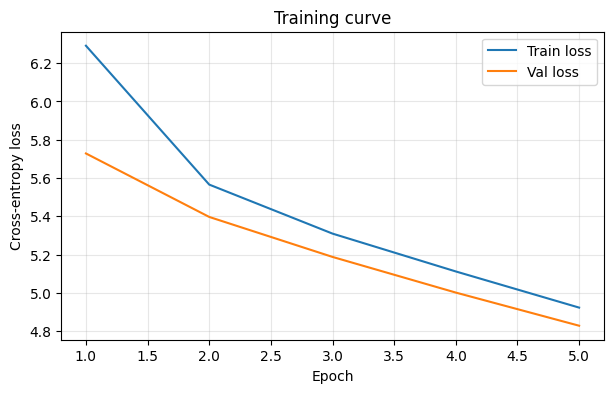

In [12]:
epochs, tr_losses, va_losses = zip(*history)

plt.figure(figsize=(7, 4))
plt.plot(epochs, tr_losses, label="Train loss")
plt.plot(epochs, va_losses, label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("Training curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


---
# 9. Legal-Move-Masked Evaluation

This is the "just mask the illegal ones" approach from our design discussion, implemented
properly:

1. Get the model's **raw, unmasked** distribution over the full vocabulary for the next move.
2. Record whether the model's own top pick (`argmax`) was *already* legal, before any masking —
   this is a **tracking-quality diagnostic**. Masking always produces a legal move regardless, so
   this is the only place we can see if the model's implicit sense of the board is drifting.
3. Compute the **true** legal moves for this position using `python-chess` on the *actual* board
   (never the model's belief about the board), mask the distribution down to those, and
   renormalize.
4. Check whether the human-played move lands in the masked Top-1 / Top-3.

Report both numbers side by side: masked Top-1/Top-3 is the metric to compare against the
LightGBM ranker baseline; `unmasked_argmax_legal_rate` tells you how much masking is doing the
heavy lifting versus the model already "knowing" the board.

Note: this loop does one forward pass per position with no KV-caching, so it's O(n²) per game —
fine for a few thousand evaluation positions, but worth optimizing (caching, batching positions
across games) before scaling this up.

In [13]:
@torch.no_grad()
def predict_next_move_distribution(move_ids_so_far):
    # Raw (unmasked) probability distribution over the full vocab for the next move.
    model.eval()
    x = torch.tensor(move_ids_so_far[-BLOCK_SIZE:], dtype=torch.long, device=device).unsqueeze(0)
    pad_mask = torch.ones_like(x, dtype=torch.bool)
    logits = model(x, pad_mask)[0, -1]
    return F.softmax(logits, dim=-1).cpu().numpy()


def legal_move_ids(board):
    return [stoi[m.uci()] for m in board.legal_moves]


def evaluate_masked_topk(games, k_values=(1, 3), max_positions=3000):
    hits = {k: 0 for k in k_values}
    total = 0
    unmasked_legal_argmax = 0

    for game in tqdm(games, desc="Evaluating"):
        if total >= max_positions:
            break

        board = game.board()
        move_ids_so_far = [BOS_ID]

        for move in game.mainline_moves():
            if total >= max_positions:
                break

            probs = predict_next_move_distribution(move_ids_so_far)

            # Diagnostic: was the model's own top pick already legal, pre-masking?
            raw_argmax_uci = itos[int(np.argmax(probs))]
            if raw_argmax_uci in {m.uci() for m in board.legal_moves}:
                unmasked_legal_argmax += 1

            legal_ids = legal_move_ids(board)
            legal_probs = probs[legal_ids]
            legal_probs = legal_probs / legal_probs.sum()

            ranked_legal_ids = [legal_ids[i] for i in np.argsort(-legal_probs)]
            played_id = stoi[move.uci()]

            for k in k_values:
                if played_id in ranked_legal_ids[:k]:
                    hits[k] += 1

            total += 1
            move_ids_so_far.append(played_id)
            board.push(move)

    results = {f"top_{k}": hits[k] / total for k in k_values}
    results["unmasked_argmax_legal_rate"] = unmasked_legal_argmax / total
    results["positions_evaluated"] = total
    return results


eval_results = evaluate_masked_topk(test_games, k_values=(1, 3), max_positions=3000)
for name, val in eval_results.items():
    print(f"{name}: {val:.4f}" if isinstance(val, float) else f"{name}: {val}")


Evaluating:   1%|█▎                                                                                                                   | 35/3000 [00:28<40:34,  1.22it/s]

top_1: 0.2693
top_3: 0.4393
unmasked_argmax_legal_rate: 0.5393
positions_evaluated: 3000


---
# 10. Save Artifacts

Persist the model weights and the vocabulary together — the vocabulary is required to decode
predictions later, and it must match exactly what the checkpoint was trained with.

In [ ]:
torch.save(model.state_dict(), "chess_gpt_baseline.pt")

with open("chess_move_vocab.json", "w") as f:
    json.dump({"itos": itos, "block_size": BLOCK_SIZE}, f)

print("Saved model weights to chess_gpt_baseline.pt")
print("Saved vocabulary to chess_move_vocab.json")


---
# 11. Summary & Next Steps

## What was built

| Component | Detail |
|---|---|
| **Data** | Same Lichess Elite 2019-10 source, ELO 2200–2600, game-level split |
| **Tokenization** | Full UCI action-space vocabulary (fixed, board-independent) |
| **Model** | From-scratch decoder-only transformer, causal self-attention, ~few million params |
| **Training** | Next-move-token cross-entropy, no legal-move masking during training |
| **Evaluation** | Legal-move-masked Top-1/Top-3 (comparable to the LightGBM ranker) + unmasked-argmax-legal-rate diagnostic |

## Direct comparison to do first

Run the LightGBM ranker's `evaluate_top1_full_ranker` / `evaluate_topk_full_ranker` and this
notebook's `evaluate_masked_topk` on the **same** `test_games` and put the numbers side by side.
That comparison is the actual answer to "did going DL help," not either number in isolation.

## Known limitations of this baseline (in priority order)

1. **No ELO conditioning.** One model across the whole 2200–2600 band, same issue flagged for the
   LightGBM baseline. Consider an ELO embedding fed alongside the move tokens, or separate models
   per band, like Maia's per-rating checkpoints.
2. **Tracking vs. deciding aren't separated in the headline metric.** `unmasked_argmax_legal_rate`
   is a start — also worth linear-probing hidden states for board state (à la Karvonen) if illegal
   argmax rate stays high after more training.
2. **Greedy vs. sampling.** Evaluation here uses ranked *lists*, not a single decoding choice, so
   this is fine for accuracy — but if you want the model to actually *play* human-like games (not
   just score well on next-move prediction), sample from the masked distribution with temperature
   rather than always taking argmax.
3. **Truncated context (`BLOCK_SIZE=160` plies).** Long games lose their opening context. Longer
   block size costs O(n²) attention compute — consider it once the short-context baseline is
   validated.
4. **No auxiliary board-state input.** The model has to infer the board purely from move history.
   An ablation worth running: concatenate a board-state embedding (e.g., from a small CNN over a
   bitboard) at each step and see how much of the gap to the LightGBM ranker that closes — this
   tells you how much of the model's job is "tracking" vs. "deciding."
5. **More data, more epochs, bigger model** — in that order, once 1–4 above are sorted, not before.
6. **Eval loop has no KV-cache**, so it's slow at scale. Fine for a baseline, worth fixing before
   evaluating on more than a few thousand positions.
